In [ ]:
# ============================================================
# Traffic Flow Prediction with MLP — Foundations of ML Project
# Dataset: Huawei Munich 6-cross traffic data (5-min readings)
# Pipeline replicates Navarro-Espinoza et al. (2022),
# tweaked for the course rubric (PyTorch MLP, >=2 hidden layers).
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, explained_variance_score)

import torch
import torch.nn as nn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
sns.set_style("whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Libraries loaded. Device:", device)

Libraries loaded. Device: cpu


In [ ]:
# Run this, click "Choose Files", pick traffic-prediction-dataset.csv
from google.colab import files
uploaded = files.upload()
FILENAME = list(uploaded.keys())[0]
print("Uploaded:", FILENAME)

Saving traffic-prediction-dataset.csv to traffic-prediction-dataset (1).csv
Uploaded: traffic-prediction-dataset (1).csv


In [ ]:
df = pd.read_csv(FILENAME)
df.columns = [c.strip() for c in df.columns]   # strip stray spaces from headers
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (16128, 6)
Columns: ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5', 'Cross 6']


,Cross 1,Cross 2,Cross 3,Cross 4,Cross 5,Cross 6
0,105.0,48.0,30,62.0,31,110.0
1,97.0,41.0,32,55.0,42,103.0
2,76.0,47.0,44,58.0,40,100.0
3,98.0,40.0,39,59.0,43,104.0
4,87.0,41.0,47,49.0,35,112.0


In [ ]:
print("=== DATA TYPES ===");          print(df.dtypes, "\n")
print("=== MISSING VALUES ===");      print(df.isna().sum(), "\n")
print("=== DUPLICATE ROWS:", df.duplicated().sum(), "\n")
print("=== SUMMARY STATISTICS ===");  display(df.describe().round(1))

# 5-min readings: 288/day * 56 days = 16128 expected
print("\nExpected rows (288*56):", 288 * 56, "| actual:", len(df))

# Zeros = likely sensor failures (the key thing we clean)
print("\n=== ZERO COUNTS PER CROSS ===")
print((df == 0).sum())

=== DATA TYPES ===
Cross 1    float64
Cross 2    float64
Cross 3      int64
Cross 4    float64
Cross 5      int64
Cross 6    float64
dtype: object 

=== MISSING VALUES ===
Cross 1    0
Cross 2    0
Cross 3    0
Cross 4    0
Cross 5    0
Cross 6    0
dtype: int64 

=== DUPLICATE ROWS: 2929 

=== SUMMARY STATISTICS ===


,Cross 1,Cross 2,Cross 3,Cross 4,Cross 5,Cross 6
count,16128.0,16128.0,16128.0,16128.0,16128.0,16128.0
mean,95.8,45.9,41.5,67.7,36.2,76.2
std,87.6,50.9,41.8,68.5,37.4,68.1
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,8.0,2.0,1.0,0.0,1.0,5.0
50%,88.0,29.0,32.0,45.0,28.0,66.0
75%,169.0,77.0,73.0,124.0,60.0,139.0
max,352.5,302.0,218.0,312.0,193.0,253.0



Expected rows (288*56): 16128 | actual: 16128

=== ZERO COUNTS PER CROSS ===
Cross 1    3615
Cross 2    3473
Cross 3    3952
Cross 4    4060
Cross 5    3947
Cross 6    3986
dtype: int64


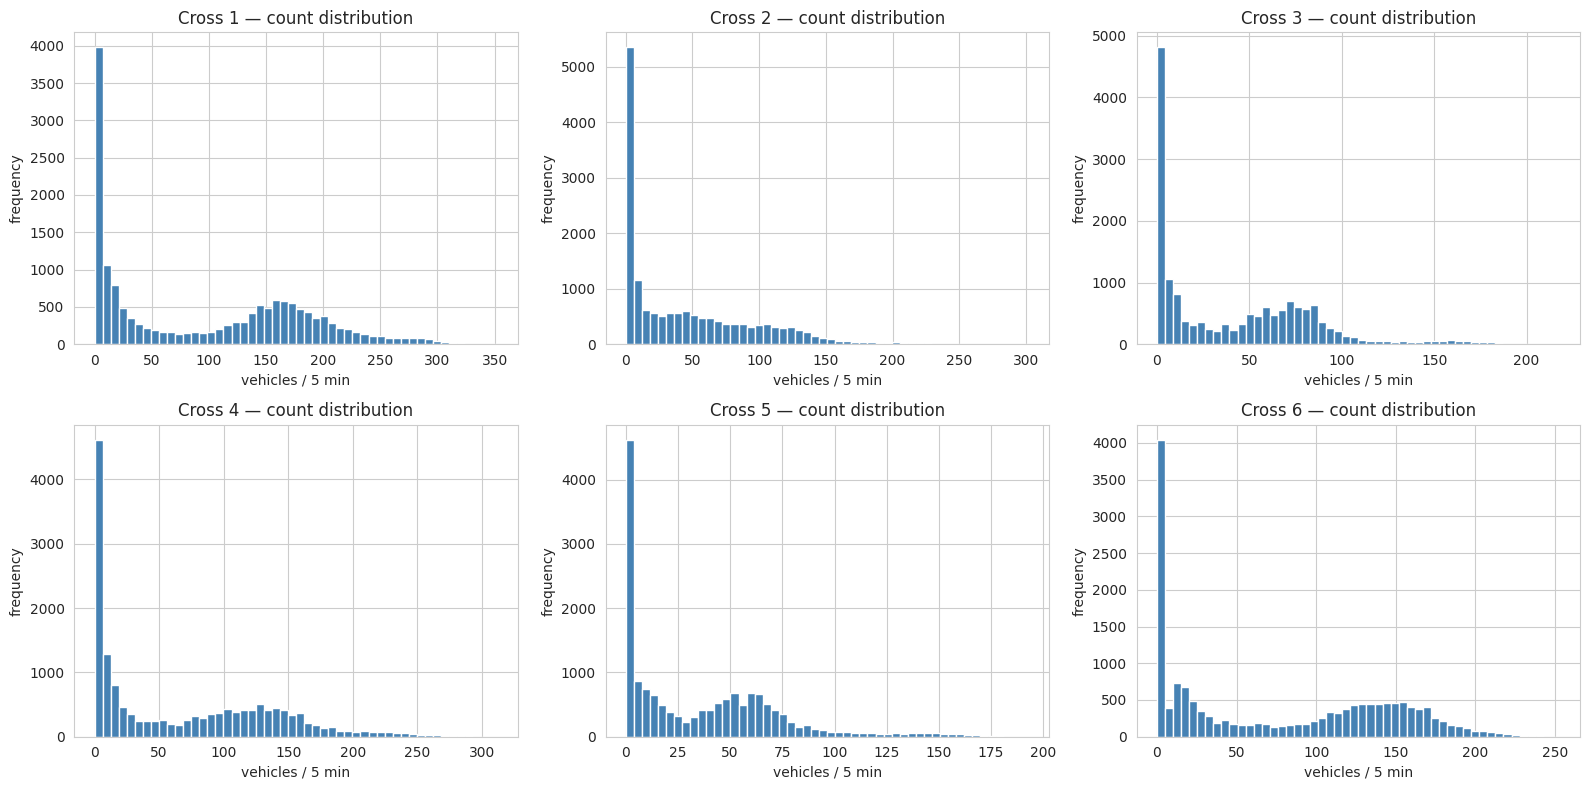

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), df.columns):
    ax.hist(df[col], bins=50, color="steelblue", edgecolor="white")
    ax.set_title(f"{col} — count distribution")
    ax.set_xlabel("vehicles / 5 min"); ax.set_ylabel("frequency")
plt.tight_layout(); plt.show()

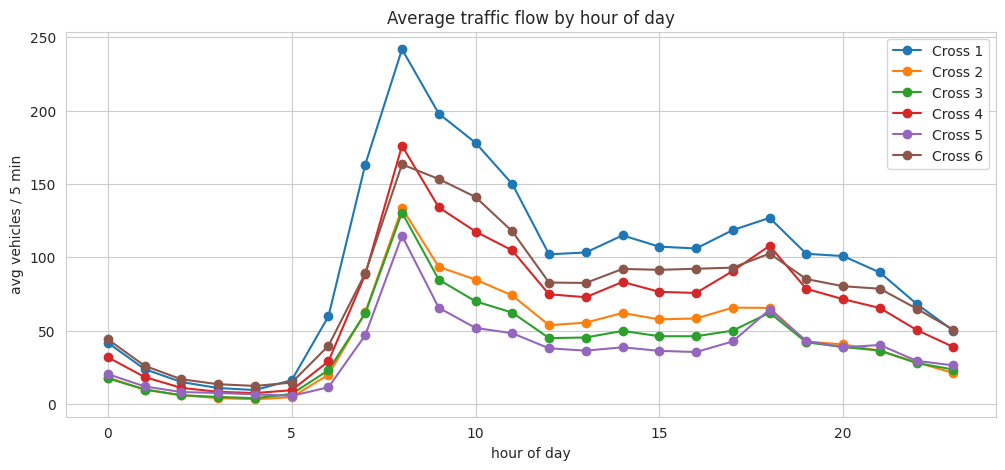

In [ ]:
# No timestamps in the data, so reconstruct time-of-day from row position
# (5-min steps, 288 readings per day).
tmp = df.copy()
tmp["hour"] = ((tmp.index % 288) * 5) // 60
hourly = tmp.groupby("hour")[list(df.columns)].mean()

plt.figure(figsize=(12, 5))
for col in df.columns:
    plt.plot(hourly.index, hourly[col], marker="o", label=col)
plt.title("Average traffic flow by hour of day")
plt.xlabel("hour of day"); plt.ylabel("avg vehicles / 5 min")
plt.legend(); plt.show()

In [ ]:
# Paper uses 4 of the 6 crosses to simulate the 4 lanes of one intersection.
LANES = ["Cross 1", "Cross 2", "Cross 3", "Cross 4"]
data = df[LANES].astype(float).copy()
print("Working data shape:", data.shape)
print("Zeros before cleaning:", int((data == 0).sum().sum()))

Working data shape: (16128, 4)
Zeros before cleaning: 15100


In [ ]:
# Paper's method: replace zeros (sensor failures) with the moving average of
# the previous 12 readings (the prior hour), NOT the column mean — this avoids
# the false spikes the column-mean approach creates.
def fix_zeros_moving_avg(series, window=12):
    vals = series.values.astype(float)
    for i in range(len(vals)):
        if vals[i] == 0:
            prev = vals[max(0, i - window):i]
            prev = prev[prev > 0]
            if len(prev) > 0:
                vals[i] = prev.mean()
    return pd.Series(vals, index=series.index)

for c in LANES:
    data[c] = fix_zeros_moving_avg(data[c])
print("Zeros after cleaning:", int((data == 0).sum().sum()))

Zeros after cleaning: 0


In [ ]:
# Time series -> split by time, never randomly (avoids data leakage).
# Paper: 75% train (~42 days), 25% test (~14 days).
split_idx = int(len(data) * 0.75)
train_raw = data.iloc[:split_idx]
test_raw  = data.iloc[split_idx:]
print(f"Train rows: {len(train_raw)} | Test rows: {len(test_raw)}")

Train rows: 12096 | Test rows: 4032


In [ ]:
# MinMax scaling to [0,1]; fit on TRAIN ONLY, then apply to test
# (fitting on test would leak information).
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)
print("Train scaled range:", round(train_scaled.min(), 3), "to", round(train_scaled.max(), 3))

Train scaled range: 0.0 to 1.0


In [ ]:
# Core idea: use the previous hour (12 readings) across all 4 lanes
# to predict the next 5-min reading for all 4 lanes.
#   X = 12 readings x 4 lanes, flattened to 48 features
#   Y = next reading for the 4 lanes
WINDOW = 12

def make_windows(arr, window=WINDOW):
    X, Y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i + window].flatten())
        Y.append(arr[i + window])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_train, Y_train = make_windows(train_scaled)
X_test,  Y_test  = make_windows(test_scaled)
print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)
print("X_test :", X_test.shape,  "| Y_test :", Y_test.shape)

X_train: (12084, 48) | Y_train: (12084, 4)
X_test : (4020, 48) | Y_test : (4020, 4)


In [ ]:
# The paper's 5 metrics. We inverse-scale predictions back to real vehicle
# counts first, so errors are in real units.
def evaluate(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(y_true_scaled).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    mask = y_true > 1e-6                      # avoid divide-by-zero in MAPE
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
        "EV":   explained_variance_score(y_true, y_pred),
    }

In [ ]:
# One-shot closed-form solver (no epochs — it solves directly).
lin = LinearRegression().fit(X_train, Y_train)
lin_results = evaluate(Y_test, lin.predict(X_test), scaler)
print("Linear Regression:", {k: round(v, 4) for k, v in lin_results.items()})

Linear Regression: {'MAE': 10.7132, 'MAPE': np.float32(22.7959), 'RMSE': np.float64(15.5883), 'R2': 0.946, 'EV': 0.946}


In [ ]:
# SGD learns iteratively over epochs. Wrapped in MultiOutputRegressor because
# plain SGDRegressor can't predict all 4 lanes at once (trains 1 model/lane).
# verbose=1 prints epoch progress; tol stops early once it converges.
sgd_base = SGDRegressor(max_iter=500, tol=1e-4, verbose=1, random_state=RANDOM_STATE)
sgd = MultiOutputRegressor(sgd_base)
print(">>> Training SGD (you'll see 4 runs — one per lane)\n")
sgd.fit(X_train, Y_train)

sgd_results = evaluate(Y_test, sgd.predict(X_test), scaler)
print("\nSGD Regressor:", {k: round(v, 4) for k, v in sgd_results.items()})
print("Epochs per lane:", [est.n_iter_ for est in sgd.estimators_])

>>> Training SGD (you'll see 4 runs — one per lane)

-- Epoch 1
Norm: 0.26, NNZs: 48, Bias: 0.031860, T: 12084, Avg. loss: 0.002834
Total training time: 0.03 seconds.
-- Epoch 2
Norm: 0.31, NNZs: 48, Bias: 0.026152, T: 24168, Avg. loss: 0.001709
Total training time: 0.07 seconds.
-- Epoch 3
Norm: 0.34, NNZs: 48, Bias: 0.022368, T: 36252, Avg. loss: 0.001474
Total training time: 0.11 seconds.
-- Epoch 4
Norm: 0.35, NNZs: 48, Bias: 0.019467, T: 48336, Avg. loss: 0.001386
Total training time: 0.13 seconds.
-- Epoch 5
Norm: 0.36, NNZs: 48, Bias: 0.018807, T: 60420, Avg. loss: 0.001338
Total training time: 0.15 seconds.
-- Epoch 6
Norm: 0.37, NNZs: 48, Bias: 0.018161, T: 72504, Avg. loss: 0.001307
Total training time: 0.17 seconds.
-- Epoch 7
Norm: 0.38, NNZs: 48, Bias: 0.016116, T: 84588, Avg. loss: 0.001283
Total training time: 0.19 seconds.
-- Epoch 8
Norm: 0.39, NNZs: 48, Bias: 0.017148, T: 96672, Avg. loss: 0.001265
Total training time: 0.22 seconds.
Convergence after 8 epochs took 0.2

In [ ]:
# Hold out last 10% of TRAIN as validation (chronological — no shuffle).
val_cut = int(len(X_train) * 0.9)
X_tr, Y_tr   = X_train[:val_cut], Y_train[:val_cut]
X_val, Y_val = X_train[val_cut:], Y_train[val_cut:]

to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=device)
X_tr_t,  Y_tr_t  = to_t(X_tr),  to_t(Y_tr)
X_val_t, Y_val_t = to_t(X_val), to_t(Y_val)
X_test_t         = to_t(X_test)
print(f"train: {len(X_tr)} | val: {len(X_val)} | test: {len(X_test)}")

train: 10875 | val: 1209 | test: 4020


In [ ]:
# Regression MLP: 48 inputs -> 4 outputs. Two hidden layers (rubric requires
# >=2). ReLU activations; LINEAR output (regression — no softmax). Same hand-
# built style as our gradient-descent assignment, adapted from classification.
class TrafficMLP(nn.Module):
    def __init__(self, in_dim=48, out_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, out_dim),
        )
    def forward(self, x):
        return self.net(x)

model = TrafficMLP(X_train.shape[1], Y_train.shape[1]).to(device)
print(model)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

TrafficMLP(
  (net): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)
Total parameters: 14788


In [ ]:
EPOCHS     = 50
BATCH_SIZE = 128
LR         = 1e-3

criterion = nn.MSELoss()                                  # regression loss
optimizer = torch.optim.Adam(model.parameters(), lr=LR)   # Adam optimizer

In [ ]:
train_losses, val_losses = [], []
n = len(X_tr_t)

for epoch in range(EPOCHS):
    # ---- train ----
    model.train()
    perm = torch.randperm(n)                 # shuffle each epoch
    running = 0.0
    for i in range(0, n, BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        xb, yb = X_tr_t[idx], Y_tr_t[idx]
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()                       # backprop
        optimizer.step()                      # update weights
        running += loss.item() * len(xb)
    train_loss = running / n

    # ---- validate ----
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), Y_val_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1:3d}/{EPOCHS}  train {train_loss:.5f}  val {val_loss:.5f}")

epoch   5/50  train 0.00176  val 0.00232
epoch  10/50  train 0.00162  val 0.00219
epoch  15/50  train 0.00158  val 0.00212
epoch  20/50  train 0.00156  val 0.00216
epoch  25/50  train 0.00155  val 0.00214
epoch  30/50  train 0.00151  val 0.00213
epoch  35/50  train 0.00151  val 0.00215
epoch  40/50  train 0.00148  val 0.00211
epoch  45/50  train 0.00147  val 0.00208
epoch  50/50  train 0.00147  val 0.00221


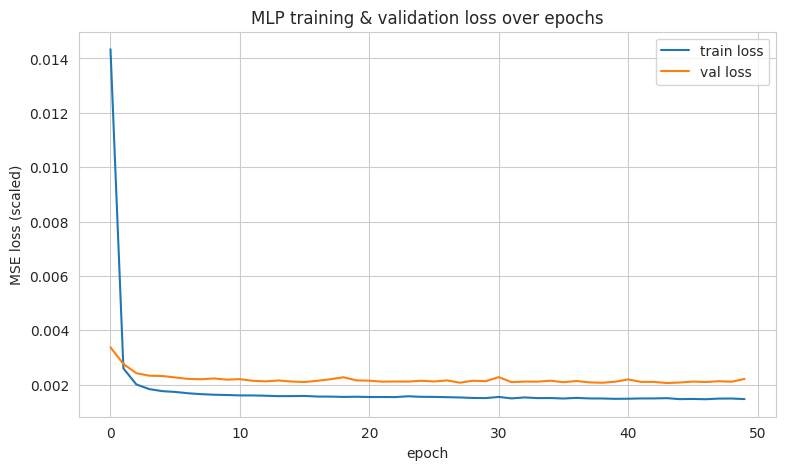

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses,   label="val loss")
plt.title("MLP training & validation loss over epochs")
plt.xlabel("epoch"); plt.ylabel("MSE loss (scaled)")
plt.legend(); plt.grid(True); plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    mlp_pred_scaled = model(X_test_t).cpu().numpy()
mlp_results = evaluate(Y_test, mlp_pred_scaled, scaler)
print("=== PyTorch MLP test metrics ===")
for k, v in mlp_results.items():
    print(f"{k:>5}: {v:.4f}")

=== PyTorch MLP test metrics ===
  MAE: 11.0248
 MAPE: 24.4516
 RMSE: 15.8347
   R2: 0.9443
   EV: 0.9461


In [ ]:
results = {
    "Linear Regression": lin_results,
    "SGD Regressor":     sgd_results,
    "MLP (PyTorch)":     mlp_results,
}
results_df = pd.DataFrame(results).T[["MAE", "MAPE", "RMSE", "R2", "EV"]].round(4)
print("=== PERFORMANCE COMPARISON (real vehicle-count units) ===")
display(results_df)
# Paper reference: MLP scored MAE 10.83, RMSE 15.42, R2 0.930, MAPE 21%

=== PERFORMANCE COMPARISON (real vehicle-count units) ===


,MAE,MAPE,RMSE,R2,EV
Linear Regression,10.7132,22.7959,15.5883,0.9460,0.9460
SGD Regressor,11.6183,25.7762,16.8825,0.9367,0.9367
MLP (PyTorch),11.0248,24.4516,15.8347,0.9443,0.9461


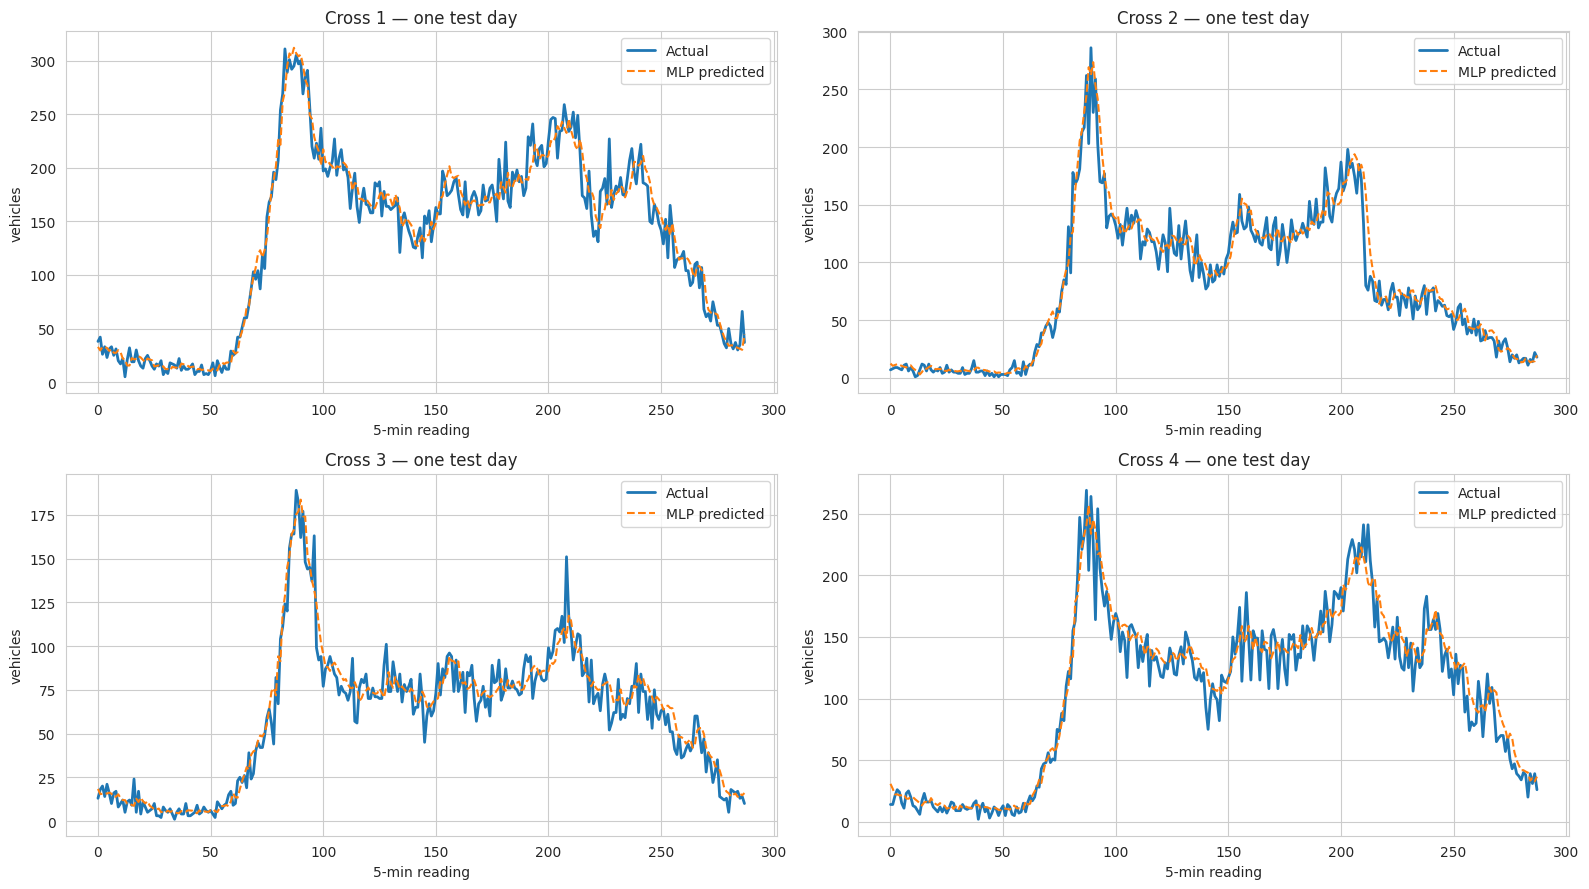

In [ ]:
y_test_real   = scaler.inverse_transform(Y_test)
mlp_pred_real = scaler.inverse_transform(mlp_pred_scaled)

ONE_DAY = 288
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for idx, (ax, lane) in enumerate(zip(axes.ravel(), LANES)):
    ax.plot(y_test_real[:ONE_DAY, idx], label="Actual", linewidth=2)
    ax.plot(mlp_pred_real[:ONE_DAY, idx], label="MLP predicted", linestyle="--")
    ax.set_title(f"{lane} — one test day")
    ax.set_xlabel("5-min reading"); ax.set_ylabel("vehicles"); ax.legend()
plt.tight_layout(); plt.show()

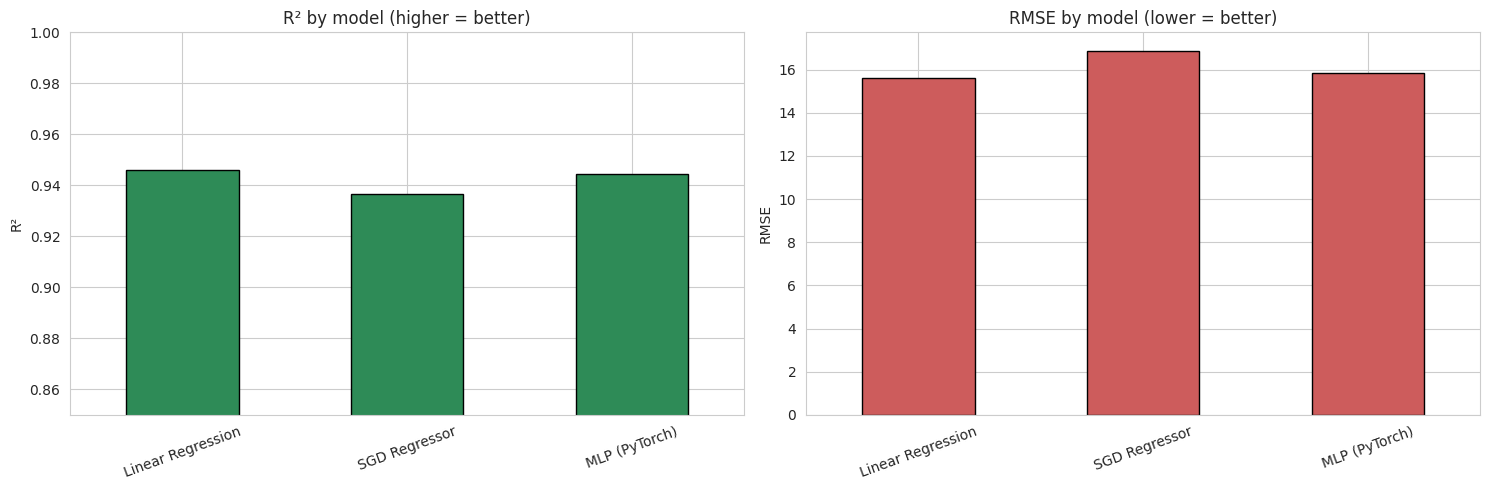

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
results_df["R2"].plot(kind="bar", ax=axes[0], color="seagreen", edgecolor="black")
axes[0].set_title("R² by model (higher = better)"); axes[0].set_ylim(0.85, 1.0)
axes[0].set_ylabel("R²"); axes[0].tick_params(axis="x", rotation=20)

results_df["RMSE"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="black")
axes[1].set_title("RMSE by model (lower = better)"); axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()